In [1]:
# Install required packages (uncomment as needed)
#!pip install transformers datasets scikit-learn torch evaluate accelerate
#!pip install sentencepiece  # needed for some tokenizers

# Core imports
import random
import numpy as np
import pandas as pd

# HuggingFace
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
from datasets import Dataset
from datasets import ClassLabel

train_df = pd.read_csv("../../data/output.csv")

dataset = Dataset.from_pandas(train_df)

print(dataset)

unique_genres = sorted(train_df["genre"].unique().tolist())
genre_feat = ClassLabel(names=unique_genres)

Dataset({
    features: ['movieId', 'title', 'genre', 'plot'],
    num_rows: 5456
})


In [3]:
MODEL_NAME = "bert-base-uncased" 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

id2label = {i: label for i, label in enumerate(unique_genres)}
label2id = {label: i for i, label in enumerate(unique_genres)}

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=19, id2label=id2label, label2id=label2id)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
def tokenize_and_encode(batch):
    # Tokenize the plot text
    tokenized = tokenizer(batch["plot"], truncation=True, padding="max_length", max_length = 512)
    # Convert text strings to integer IDs
    tokenized["labels"] = [genre_feat.str2int(label) for label in batch["genre"]]
    return tokenized

dataset_bert = dataset.map(tokenize_and_encode, batched=True, remove_columns=dataset.column_names)
dataset_split = dataset_bert.train_test_split(test_size=0.2, seed=SEED)

Map:   0%|          | 0/5456 [00:00<?, ? examples/s]

In [5]:
training_args = TrainingArguments(
    output_dir = "./results",
    num_train_epochs = 3,
    per_device_train_batch_size = 8,
    learning_rate = 2e-5,
    logging_steps = 10,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True, 
    seed = SEED
)

def metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions), 
        "f1": f1_score(labels, predictions, average="weighted")
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset = dataset_split["train"],
    eval_dataset = dataset_split["test"],
    compute_metrics = metrics 
)

trainer.train()

/opt/miniconda3/envs/ass4/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.272124,1.502017,0.529304,0.481940
2,1.256864,1.478709,0.543040,0.504227
3,0.839731,1.481680,0.558608,0.531854


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/envs/ass4/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/envs/ass4/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1638, training_loss=1.2633933939485469, metrics={'train_runtime': 2029.0578, 'train_samples_per_second': 6.452, 'train_steps_per_second': 0.807, 'total_flos': 3445175714844672.0, 'train_loss': 1.2633933939485469, 'epoch': 3.0})

In [10]:
best_run_logs = [log for log in trainer.state.log_history if "eval_accuracy" in log]

if best_run_logs:
    print("--- Final Best Model Metrics ---")
    print(best_run_logs[-1])

    last_log = best_run_logs[-1]

    model_accuracy = last_log["eval_accuracy"]
    model_f1 = last_log["eval_f1"]
    
    print(f"Variables Saved! Accuracy: {model_accuracy}")
    print(f"F1 (Weighted): {model_f1}")
   
else:
    print("No logs found. Let's try a direct prediction...")

--- Final Best Model Metrics ---
{'eval_loss': 1.481680154800415, 'eval_accuracy': 0.5586080586080586, 'eval_f1': 0.5318537947468565, 'eval_runtime': 29.3801, 'eval_samples_per_second': 37.168, 'eval_steps_per_second': 4.663, 'epoch': 3.0, 'step': 1638}
Variables Saved! Accuracy: 0.5586080586080586
F1 (Weighted): 0.5318537947468565


In [12]:
#scores from baseline models:
maj_f1 = 0.1135253434892441
rand_f1 = 0.06797697750182068
maj_accuracy = 0.2683150183150183
rand_accuracy = 0.047619047619047616

comparison_df = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Random Baseline",
        "Bert-Base-Uncased Model"
    ],
    "F1 (Weighted)": [
        maj_f1,
        rand_f1,
        model_f1
    ],
    "Accuracy": [
        maj_accuracy,
        rand_accuracy,
        model_accuracy
    ]
})

comparison_df

,Model,F1 (Weighted),Accuracy
0,Majority Baseline,0.113525,0.268315
1,Random Baseline,0.067977,0.047619
2,Bert-Base-Uncased Model,0.531854,0.558608


  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.9 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 81.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


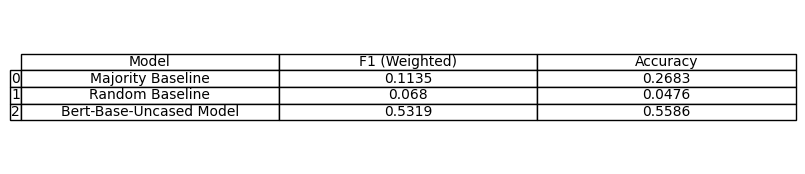

In [15]:
!pip install matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2))

ax.axis('off')

table = pd.plotting.table(
    ax,
    comparison_df.round(4),
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)

plt.savefig('comparison-results.png', bbox_inches='tight', dpi=150)
plt.show()

/opt/miniconda3/envs/ass4/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


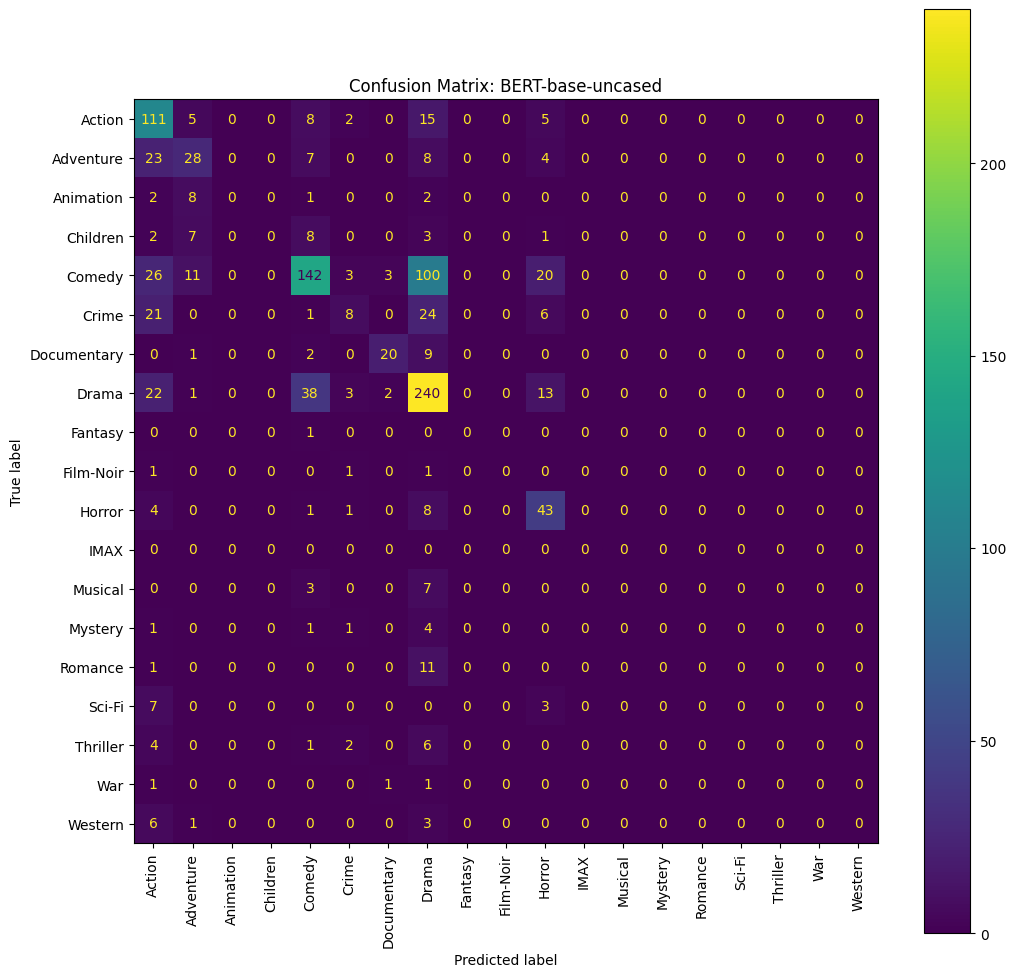

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

output = trainer.predict(dataset_split["test"])
y_true = output.label_ids
y_pred = np.argmax(output.predictions, axis=1)

all_label_ids = list(range(len(unique_genres))) 
cm = confusion_matrix(y_true, y_pred, labels=all_label_ids)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_genres)

disp.plot(xticks_rotation=90, ax=ax, values_format='d')

plt.title("Confusion Matrix: BERT-base-uncased")
plt.savefig('confusion-matrix.png', bbox_inches='tight', dpi=150)
plt.show()